In [1]:
import os
from datetime import datetime
from pathlib import Path

from tqdm.auto import tqdm

from scripts import (
    anisotropy,
    config_loader,
    geostat,
    ml,
    postproc,
    preproc_data,
    preproc_grid,
    preproc_ml,
    read,
    visualisation,
    write,
    xval,
)


In [2]:
cfg = config_loader.load_config(Path(os.getcwd()) / "config.yaml")


loading config from c:\WERK\GIT\FRESHEM_3D_interpolation\config.yaml
loading local overrides from c:\WERK\GIT\FRESHEM_3D_interpolation\config.local.yaml


In [3]:
data = read.table(cfg["path_preproc_data"])
pred = read.dataset(cfg["path_prediction"])

In [4]:
from scipy.spatial import cKDTree
import xarray as xr
import numpy as np

idw_power = 2
idw_k_nearest = 32

# select input data
df = data.loc[data["layer"] == 1, ["x", "y", "z_top"]].dropna()

xy_data = df[["x", "y"]].to_numpy()
z_data = df["z_top"].to_numpy()

tree = cKDTree(xy_data)

# grid coords
x = pred.coords["x"].values
y = pred.coords["y"].values
xx, yy = np.meshgrid(x, y, indexing="xy")

#get mask
mask = pred["mask"].values

# target points (only inside mask)
xy_target = np.column_stack([xx[mask], yy[mask]])

# query
dist, idx = tree.query(xy_target, k=idw_k_nearest)


# weights
valid = np.isfinite(dist)
w = np.zeros_like(dist, dtype=float)
w[valid] = 1.0 / dist[valid] ** idw_power

z_top_pred = np.full(len(xy_target), np.nan, dtype=np.float32)


# handle exact hits
exact = (dist == 0) & valid
has_exact = exact.any(axis=1)

if has_exact.any():
    first = exact.argmax(axis=1)
    z_top_pred[has_exact] = z_data[idx[has_exact, first[has_exact]]]

# normal IDW
todo = ~has_exact & valid.any(axis=1)
z_top_pred[todo] = (
    np.sum(w[todo] * z_data[idx[todo]], axis=1)
    / np.sum(w[todo], axis=1)
)

# create 2D output
model_top = xr.full_like(pred["mask"], np.nan, dtype=np.float32)
model_top.values[pred["mask"].values] = z_top_pred

# initialise + assign
pred["top"] = xr.full_like(
    pred["mask"].expand_dims(layer=pred["layer"]).transpose("layer", "y", "x"),
    np.nan,
    dtype=np.float32,
)

pred["top"].loc[{"layer": 1}] = model_top



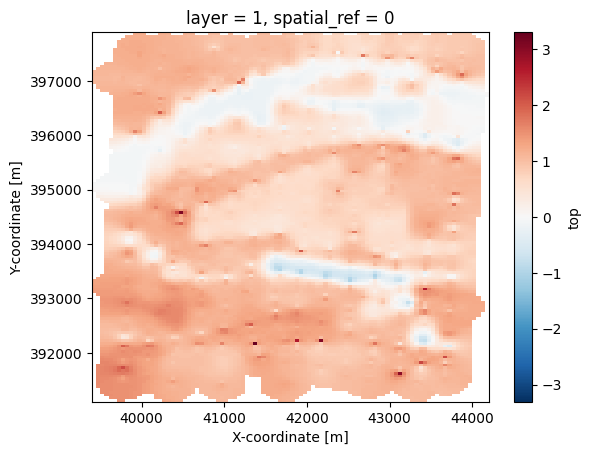

In [5]:
pred["top"].sel(layer=1).plot()

In [6]:
import numpy as np

tol = 1e-9

is_constant = data.groupby("layer")["thickness"].apply(
    lambda s: np.allclose(s, s.iloc[0], atol=tol, rtol=0, equal_nan=False)
)


if not is_constant.all():
    invalid_layers = is_constant[~is_constant].index.tolist()
    raise ValueError(f"Thickness is not constant within layer(s): {invalid_layers}")

thickness_by_layer = (
    data.groupby("layer")["thickness"]
    .first()
    .to_dict()
)
thickness_by_layer

{1: 0.5,
 2: 0.5707,
 3: 0.6513,
 4: 0.7434,
 5: 0.8484,
 6: 0.9683,
 7: 1.105,
 8: 1.261,
 9: 1.44,
 10: 1.643,
 11: 1.875,
 12: 2.14,
 13: 2.443,
 14: 2.788,
 15: 3.182,
 16: 3.632,
 17: 4.145,
 18: 4.731,
 19: 5.399,
 20: 6.162,
 21: 7.033,
 22: 8.027,
 23: 9.162,
 24: 10.46,
 25: 11.93,
 26: 13.62,
 27: 15.55,
 28: 17.74,
 29: 20.25,
 30: 80.0001}

In [13]:
pred["bottom"] = xr.full_like(pred["top"], np.nan, dtype=np.float32)
for layer, thickness in thickness_by_layer.items():
    if not layer == 1:
        pred["top"].loc[{"layer": layer}] = pred["top"].sel(layer=layer - 1) - thickness
    pred["bottom"].loc[{"layer": layer}] = pred["top"].sel(layer=layer) - thickness

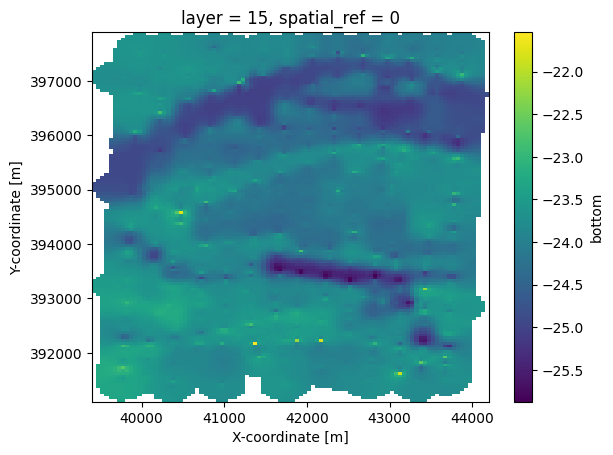

In [14]:
pred["bottom"].sel(layer=15).plot()

In [9]:
pred

<xarray.Dataset> Size: 17MB
Dimensions:      (y: 136, x: 96, layer: 30)
Coordinates:
  * y            (y) float64 1kB 3.911e+05 3.912e+05 ... 3.978e+05 3.979e+05
  * x            (x) float64 768B 3.942e+04 3.948e+04 ... 4.412e+04 4.418e+04
  * layer        (layer) int64 240B 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
    spatial_ref  int64 8B ...
Data variables:
    mask         (y, x) bool 13kB False False False False ... False False False
    P(rho≤1)     (layer, y, x) float32 2MB ...
    P(rho≤2)     (layer, y, x) float32 2MB ...
    P(rho≤3)     (layer, y, x) float32 2MB ...
    P(rho≤5)     (layer, y, x) float32 2MB ...
    P(rho≤10)    (layer, y, x) float32 2MB ...
    P(rho≤20)    (layer, y, x) float32 2MB ...
    P(rho≤30)    (layer, y, x) float32 2MB ...
    P(rho≤50)    (layer, y, x) float32 2MB ...
    P(rho≤100)   (layer, y, x) float32 2MB ...
    top          (layer, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
    bottom       (layer, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
Attributes:
    cellsize_x:  50
    cellsize_y:  50

In [10]:
data

,line_no,x,y,layer,rho,rho_std,z_top,z_bottom,thickness,z_doi_conservative,...,P(rho≤30),P(rho≤50),P(rho≤100),Q(0.05),Q(0.1),Q(0.25),Q(0.5),Q(0.75),Q(0.9),Q(0.95)
296160,890402,39701.06,397059.75,1,5.847,1.138,1.0000,0.5000,0.5000,-61.911,...,1.0,1.0,1.0,3.975157,4.388594,5.079431,5.847000,6.614569,7.305406,7.718843
296161,890402,39701.06,397059.75,2,6.659,1.129,0.5000,-0.0707,0.5707,-61.911,...,1.0,1.0,1.0,4.801960,5.212128,5.897501,6.659000,7.420499,8.105872,8.516040
296162,890402,39701.06,397059.75,3,9.167,1.123,-0.0707,-0.7220,0.6513,-61.911,...,1.0,1.0,1.0,7.319829,7.727818,8.409548,9.167000,9.924452,10.606182,11.014171
296163,890402,39701.06,397059.75,4,9.978,1.115,-0.7220,-1.4654,0.7434,-61.911,...,1.0,1.0,1.0,8.143989,8.549070,9.225944,9.978000,10.730056,11.406930,11.812012
296164,890402,39701.06,397059.75,5,17.620,1.101,-1.4654,-2.3138,0.8484,-61.911,...,1.0,1.0,1.0,15.809016,16.209011,16.877386,17.620001,18.362614,19.030989,19.430984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687925,890402,43878.78,396753.54,26,4.450,1.179,-93.0401,-106.6600,13.6200,-40.165,...,1.0,1.0,1.0,2.510718,2.939051,3.654777,4.450000,5.245224,5.960949,6.389282
687926,890402,43878.78,396753.54,27,4.592,1.191,-106.6600,-122.2100,15.5500,-40.165,...,1.0,1.0,1.0,2.632979,3.065672,3.788683,4.592000,5.395317,6.118328,6.551021
687927,890402,43878.78,396753.54,28,4.684,1.203,-122.2100,-139.9500,17.7400,-40.165,...,1.0,1.0,1.0,2.705241,3.142293,3.872589,4.684000,5.495411,6.225707,6.662759
687928,890402,43878.78,396753.54,29,4.741,1.215,-139.9500,-160.2000,20.2500,-40.165,...,1.0,1.0,1.0,2.742503,3.183915,3.921495,4.741000,5.560505,6.298085,6.739497


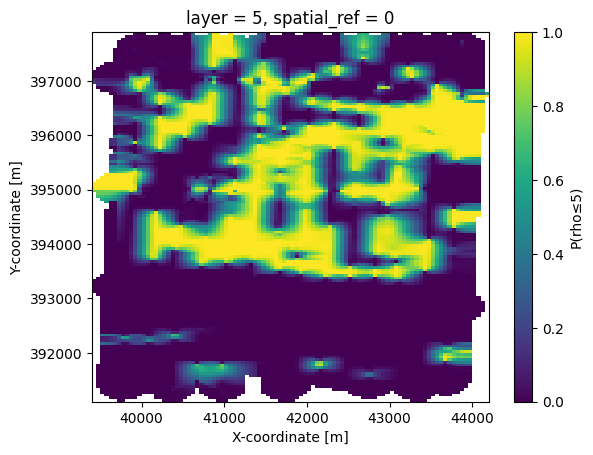

In [11]:
pred['P(rho≤5)'].sel(layer=5).plot()

In [12]:
from scripts import write
write.ds_to_tiff(pred, cfg["dir_rasters"], "pred")